In [1]:
from langgraph.graph import StateGraph, START, END
from typing import Literal, Optional, TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()  # Load environment variables from .env file

model = ChatOpenAI()

In [3]:
class JokeState(TypedDict):
    joke : str
    topic : str
    explanation : str
    

In [4]:
def GenerateJoke(state: JokeState) :

    prompt = f"Generate a joke about {state['topic']}."
    response = model.invoke(prompt).content

    return {'joke': response}

def ExplainJoke(state: JokeState) :
    promt = f"Explain the joke: {state['joke']}."
    response = model.invoke(promt).content

    return {'explanation': response}

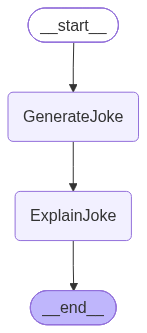

In [5]:
#build the state graph

graph = StateGraph(JokeState)

# build nodes 

graph.add_node('GenerateJoke', GenerateJoke)
graph.add_node('ExplainJoke', ExplainJoke)

# build edges

graph.add_edge(START, 'GenerateJoke')
graph.add_edge('GenerateJoke', 'ExplainJoke')
graph.add_edge('ExplainJoke', END)

# persistance in memory

checkpoint = InMemorySaver()

# compile the graph
workflow = graph.compile(checkpointer =checkpoint)

workflow

In [7]:
config1 = {"configurable" :{"thread_id": "1"} }

workflow.invoke({'topic': 'programming'}, config = config1)

{'joke': 'Why do programmers prefer dark mode? \nBecause the light attracts bugs!',
 'topic': 'programming',
 'explanation': 'This joke plays on the double meaning of the word "bugs." In programming, a "bug" refers to an error or flaw in the code that causes unexpected behavior. Light can attract bugs like insects, but in this context, the joke implies that light mode in programming might attract more errors or bugs, which programmers want to avoid. This is why they prefer dark mode, which has a darker color palette and may be easier on the eyes for long periods of coding.'}

In [8]:
workflow.get_state(config = config1)

StateSnapshot(values={'joke': 'Why do programmers prefer dark mode? \nBecause the light attracts bugs!', 'topic': 'programming', 'explanation': 'This joke plays on the double meaning of the word "bugs." In programming, a "bug" refers to an error or flaw in the code that causes unexpected behavior. Light can attract bugs like insects, but in this context, the joke implies that light mode in programming might attract more errors or bugs, which programmers want to avoid. This is why they prefer dark mode, which has a darker color palette and may be easier on the eyes for long periods of coding.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1be66e-caf1-6aae-8002-d87883d7d662'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-10-02T13:41:09.203601+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1be66e-b54d-616c-8001-d59c250f2f88'}}, tasks=(), interrupts=())

In [9]:
list(workflow.get_state_history(config = config1))

[StateSnapshot(values={'joke': 'Why do programmers prefer dark mode? \nBecause the light attracts bugs!', 'topic': 'programming', 'explanation': 'This joke plays on the double meaning of the word "bugs." In programming, a "bug" refers to an error or flaw in the code that causes unexpected behavior. Light can attract bugs like insects, but in this context, the joke implies that light mode in programming might attract more errors or bugs, which programmers want to avoid. This is why they prefer dark mode, which has a darker color palette and may be easier on the eyes for long periods of coding.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1be66e-caf1-6aae-8002-d87883d7d662'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-10-02T13:41:09.203601+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1be66e-b54d-616c-8001-d59c250f2f88'}}, tasks=(), interrupts=()),
 StateS

In [ ]:
### TIMETRAVEL